# Data Understanding and Description
## Ames Housing Dataset Description:

The Ames Housing dataset is a complete set of real estate data with details of residential homes in Ames, Iowa, and it has 1,460 observations and 81 variables with information on different attributes of homes:

## Key Features:
- **General Property Details**: Size (living space, lot size), position (neighbourhood), and type (building style, zoning)  
- **Quality Indicators**: Total score and overall grade (1-10 scale)  
- **Interior Features**: Bedroom count, number of bedrooms, bathroom count, kitchen quality and basement information  
- **Exterior Features:** Porch areas, masonry veneer, foundation, exterior materials, and type of roof  
- **Garage Details:** Type, size, capacity, and condition  
- **Land Characteristics**: Lot shape, contour, and design  
- **Chronological Information**: Year constructed, renovated, and sold  

## Target Variable:
- **SalePrice**: Sale price of the property in dollars  

Both categorical and numerical variables with missing data of different levels form the composition of the dataset. It is widely employed in regression modeling, practice of feature engineering, and real estate price prediction problems. Due to the large set of features, it is useful in analyzing high-level relationships between various properties of houses and market price.

In [ ]:
# for EDA /-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis (EDA)

## Part 1: Exploratory Data Analysis
This section covers the initial analysis of the dataset.


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv')
print(f'The number of rows and columns in the dataset are: {df.shape}')

The number of rows and columns in the dataset are: (1460, 81)


In [ ]:
# Preview the dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
# Statistical summary
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
df.duplicated().value_counts()

,count
False,1460


In [ ]:
# Checking for missing values
# Missing values Analysis
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values_percentage = (missing_values / len(df))* 100

# concatenating the missing values and percentages values
missing_data = pd.concat([missing_values, missing_values_percentage], axis = 1)
missing_data.columns = ['missing values', 'pct of missing vals']
print(missing_data[missing_data['missing values']> 0])

              missing values  pct of missing vals
PoolQC                  1453            99.520548
MiscFeature             1406            96.301370
Alley                   1369            93.767123
Fence                   1179            80.753425
MasVnrType               872            59.726027
FireplaceQu              690            47.260274
LotFrontage              259            17.739726
GarageQual                81             5.547945
GarageFinish              81             5.547945
GarageType                81             5.547945
GarageYrBlt               81             5.547945
GarageCond                81             5.547945
BsmtFinType2              38             2.602740
BsmtExposure              38             2.602740
BsmtCond                  37             2.534247
BsmtQual                  37             2.534247
BsmtFinType1              37             2.534247
MasVnrArea                 8             0.547945
Electrical                 1             0.068493


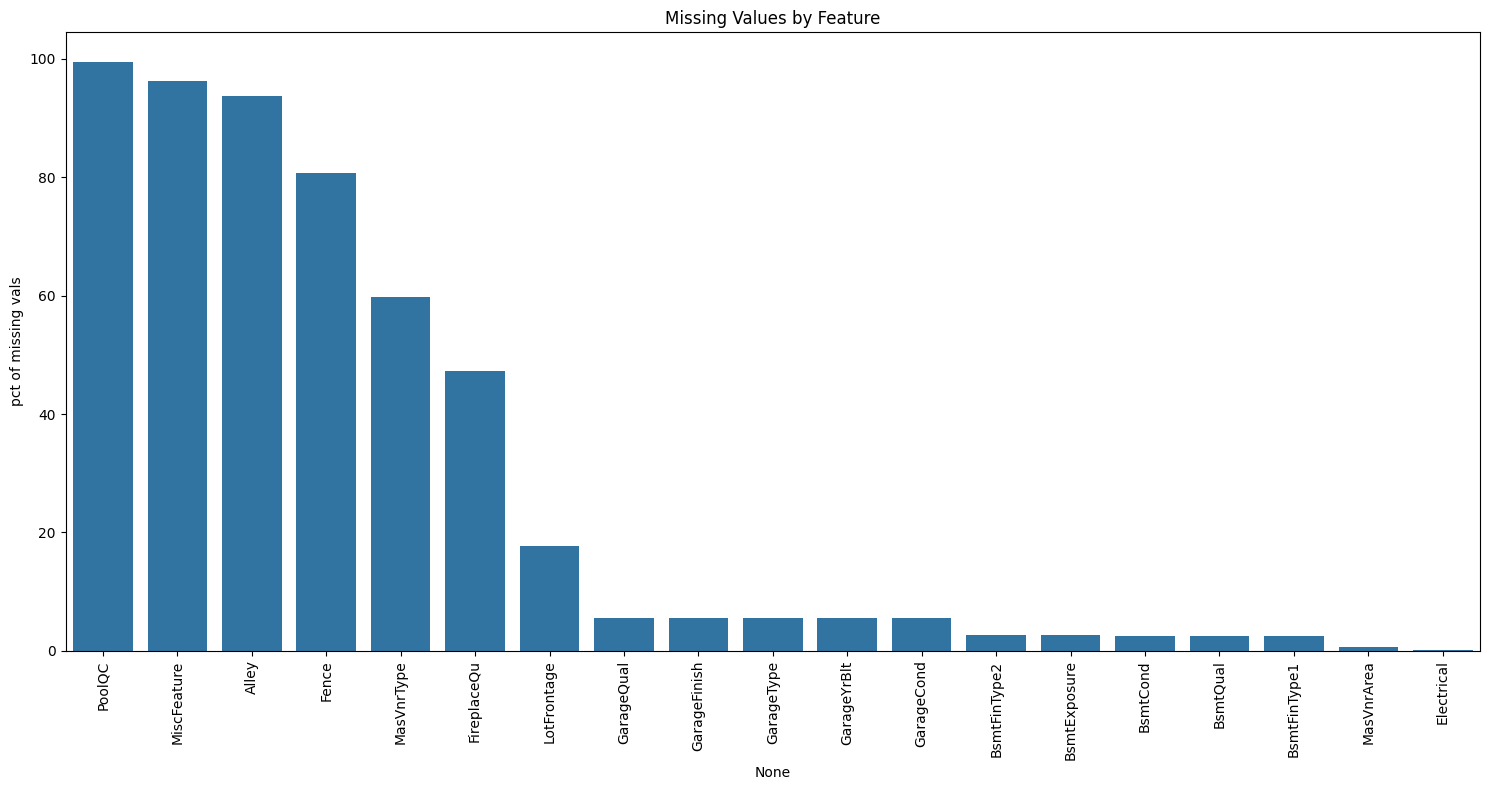

In [ ]:
# Visualization
plt.figure(figsize = (15, 8))
# Filter for missing data where the percentage is greater than 0
missing_data = missing_data[missing_data['pct of missing vals'] > 0]

# Sort values by percentage of missing values in descending order
missing_data.sort_values(by = 'pct of missing vals', ascending = False, inplace = True)

sns.barplot(x = missing_data.index, y = missing_data['pct of missing vals'])
plt.xticks(rotation = 90)
plt.title('Missing Values by Feature')
plt.tight_layout()
plt.show()

## Missing Value Analysis

1. From  these information we can already see thta some features won't be relevant in our exploratory data analysis.
2. As there are to much missing values in (such columns as Alley and PoolQC)
3. There are too much features to analyse that it may be a better approach if we only concentrate on the one which are actually giving meaningful insights
4. Removing noise columns and the features with 30% or less NaN values

In [ ]:
df2 = df[[column for column in df if df[column]. count() / len(df) >= 0.3]]
del df2['Id']
print('List of dropped columns:', end = ' ')
for column in df.columns:
  if column not in df2.columns:
    print(column, end = ', ')

print('\n')
df = df2

List of dropped columns: Id, Alley, PoolQC, Fence, MiscFeature, 



In [ ]:
df2.isna().sum().sort_values(ascending=False)

,0
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


### Exploring the Target Variable

In [ ]:
df2['SalePrice'].describe().T

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


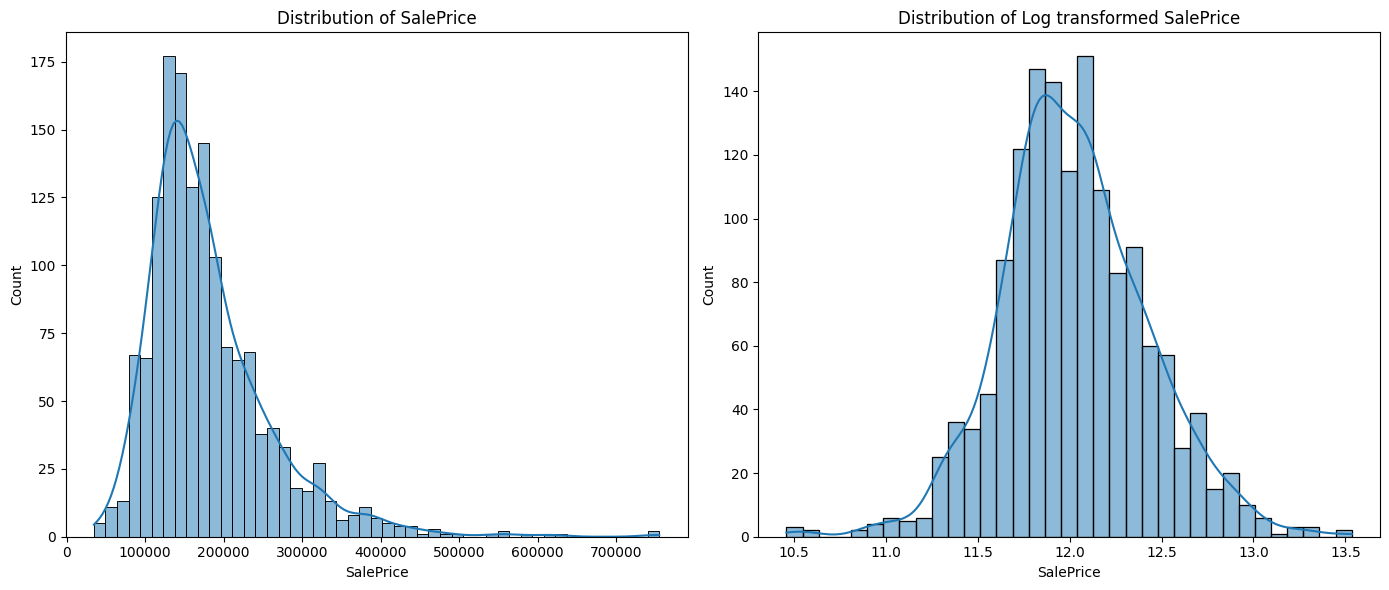

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize = (14, 6))
# original sales price distribution
sns.histplot(df2['SalePrice'], kde= True, ax = axes[0])
axes[0].set_title('Distribution of SalePrice')

# log transformed sales price distribution
sns.histplot(np.log1p(df['SalePrice']), kde= True, ax = axes[1])
axes[1].set_title('Distribution of Log transformed SalePrice')
plt.tight_layout()
plt.show()

Distribution of Target Variable is indicating that distribution of column SalePrice is skewed towards right hand side hence we have applied numpy log transformation technique in order to normalize distribution of target variable.

### Calculating the skewness of the target valriable.

In [ ]:
df2['SalePrice'].skew()

np.float64(1.8828757597682129)

### Log tranformation normalizes the skewness of Variable

In [ ]:
np.log1p(df2['SalePrice'].skew())

np.float64(1.0587883236479845)

## Correlation Analysis


In [ ]:
numeric_features= df2.select_dtypes(include = [np.number])
correlation = numeric_features.corr()['SalePrice'].sort_values(ascending = False)

In [ ]:
numeric_features.head(3)

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500


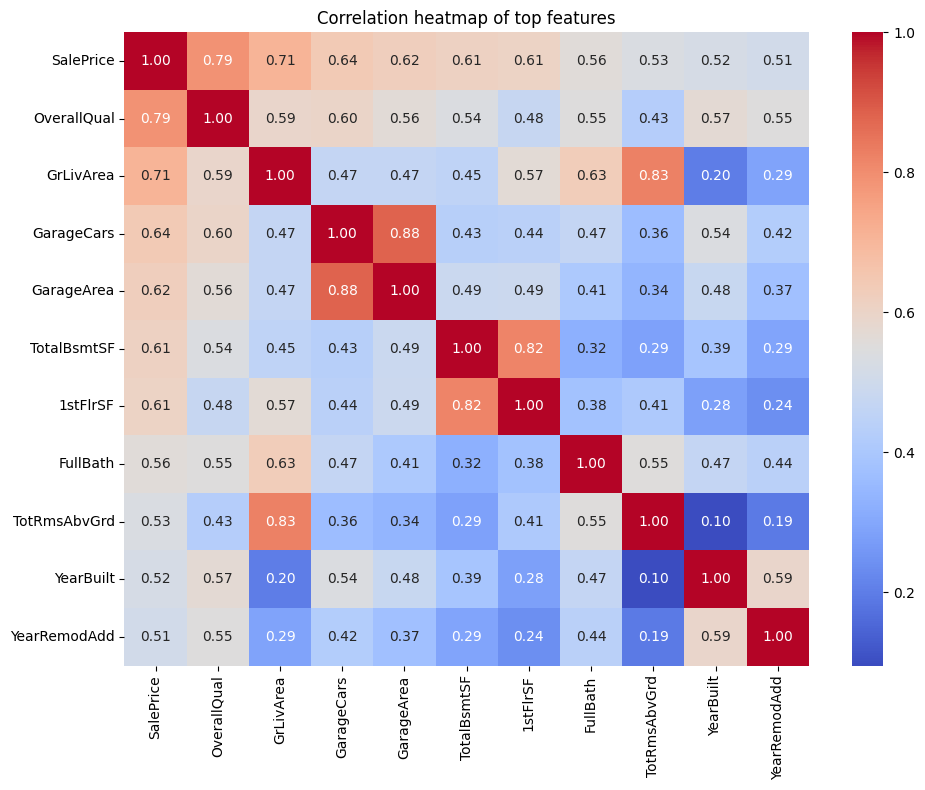

In [ ]:
# Visualization
# Heatmap of top highly correlated features
plt.figure(figsize=(10,8))
top_corr_features = correlation.index[:11]
top_corr_df = df2[top_corr_features].corr()
sns.heatmap(top_corr_df, annot = True, cmap = 'coolwarm', fmt='.2f')
plt.title('Correlation heatmap of top features')
plt.tight_layout()
plt.show()

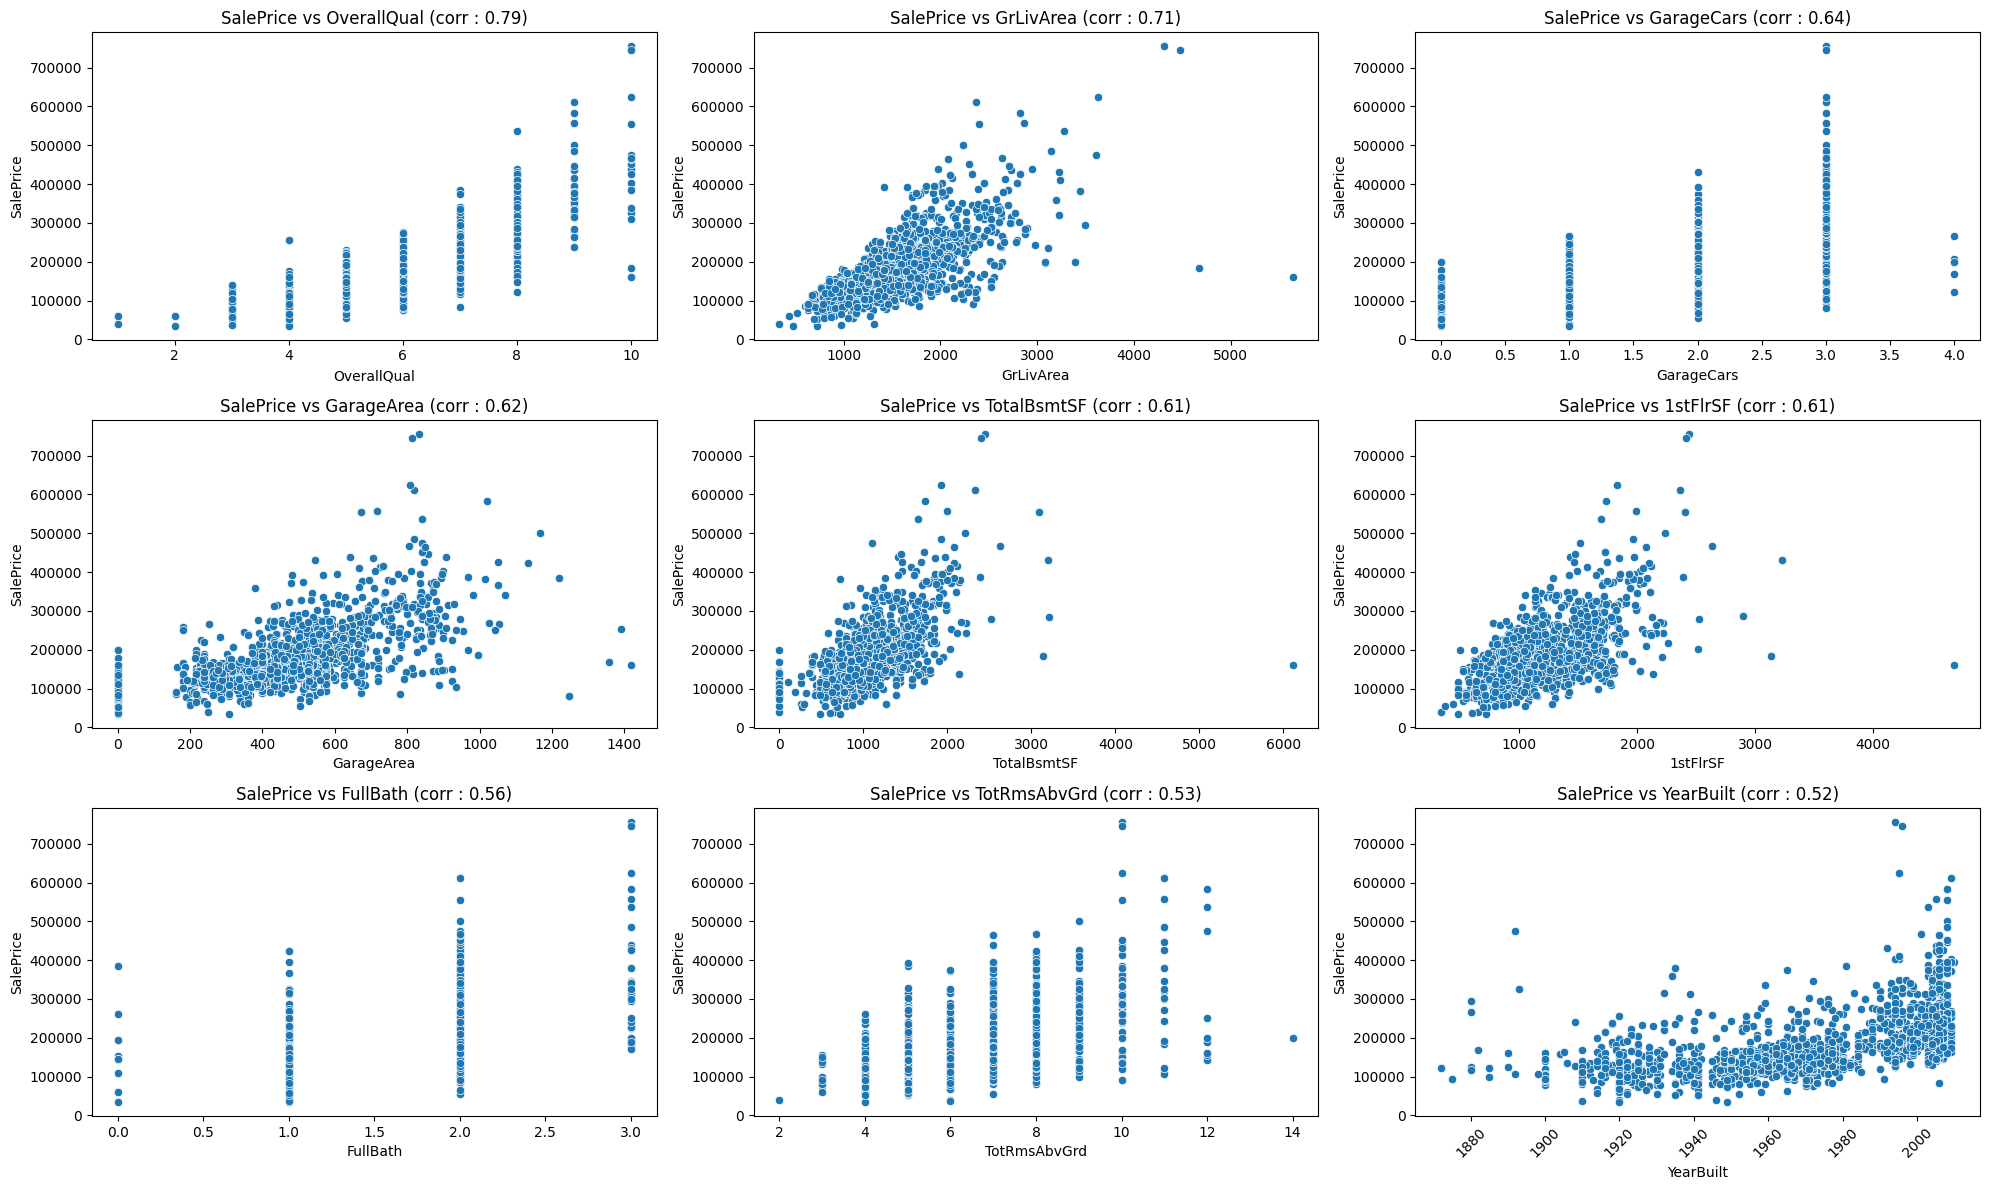

In [ ]:
# Visualization
# Scatter plot of top 9 correlated features
plt.figure(figsize = (20, 12))
for i, features in enumerate(correlation.index[1:10]): #excluding target variable

  plt.subplot(3, 3, i+1)
  sns.scatterplot(x = df2[features], y = df2['SalePrice'])
  plt.title(f'SalePrice vs {features} (corr : {correlation[features]:.2f})')
  if features == 'YearBuilt' or features == 'YearRemodAdd':
    plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

**All the top highly correlated variables suggest a strong linear relationship between these features and the target variable, 'SalePrice'**

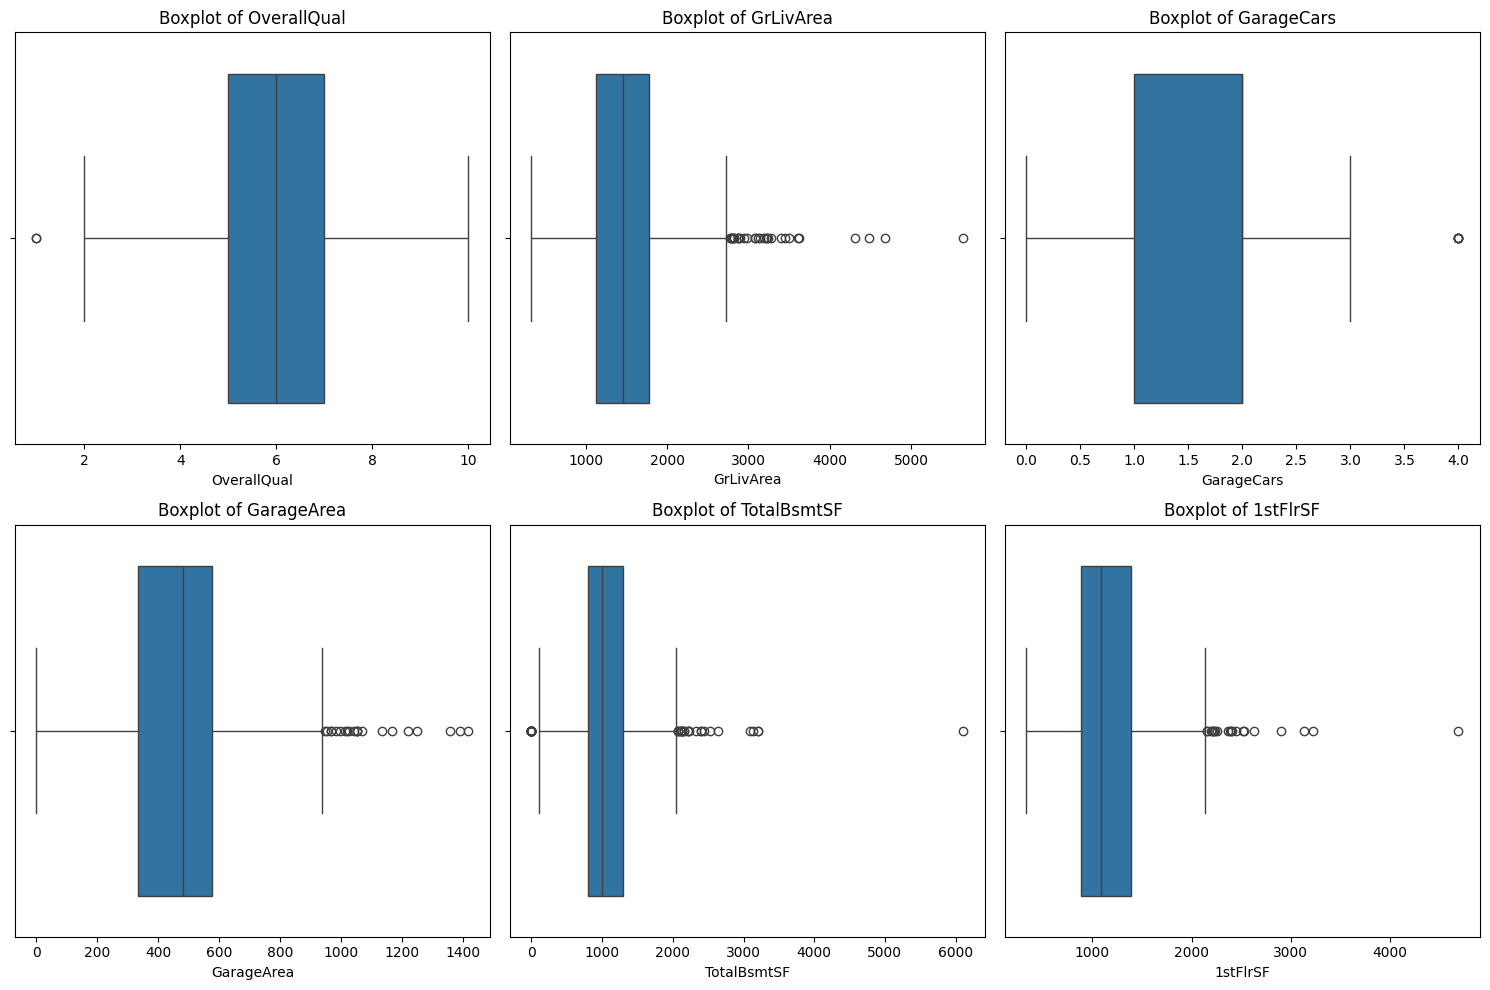

In [ ]:
# Visualization
# outlier detection
plt.figure(figsize=(15, 10))
for i, features in enumerate(correlation.index[1:7]):
  plt.subplot(2, 3, i+1)
  sns.boxplot(x = df2[features])
  plt.title(f'Boxplot of {features}')

plt.tight_layout()
plt.show()

###Z-Score Outlier detection

In [ ]:
# Use the list of column names to select data from df2
z_scores = stats.zscore(df2[numeric_features.columns].fillna(df2[numeric_features.columns].mean()))

abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3).all(axis=1)

df_no_outliers = df2[filtered_entries]
print(f'\nNumber of data points remaining after removing outliers: {len(df_no_outliers)}')

print(f'Number of outliers detected by Z-score: {len(df) - len(df_no_outliers)}')


Number of data points remaining after removing outliers: 1015
Number of outliers detected by Z-score: 445


### Categorical Features analysis

In [ ]:
cat_features = df2.select_dtypes(include=['object']).columns
print(f'Number of categorical features: {len(cat_features)}')
print(f'Categorical features: {cat_features.tolist()}')

Number of categorical features: 39
Categorical features: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


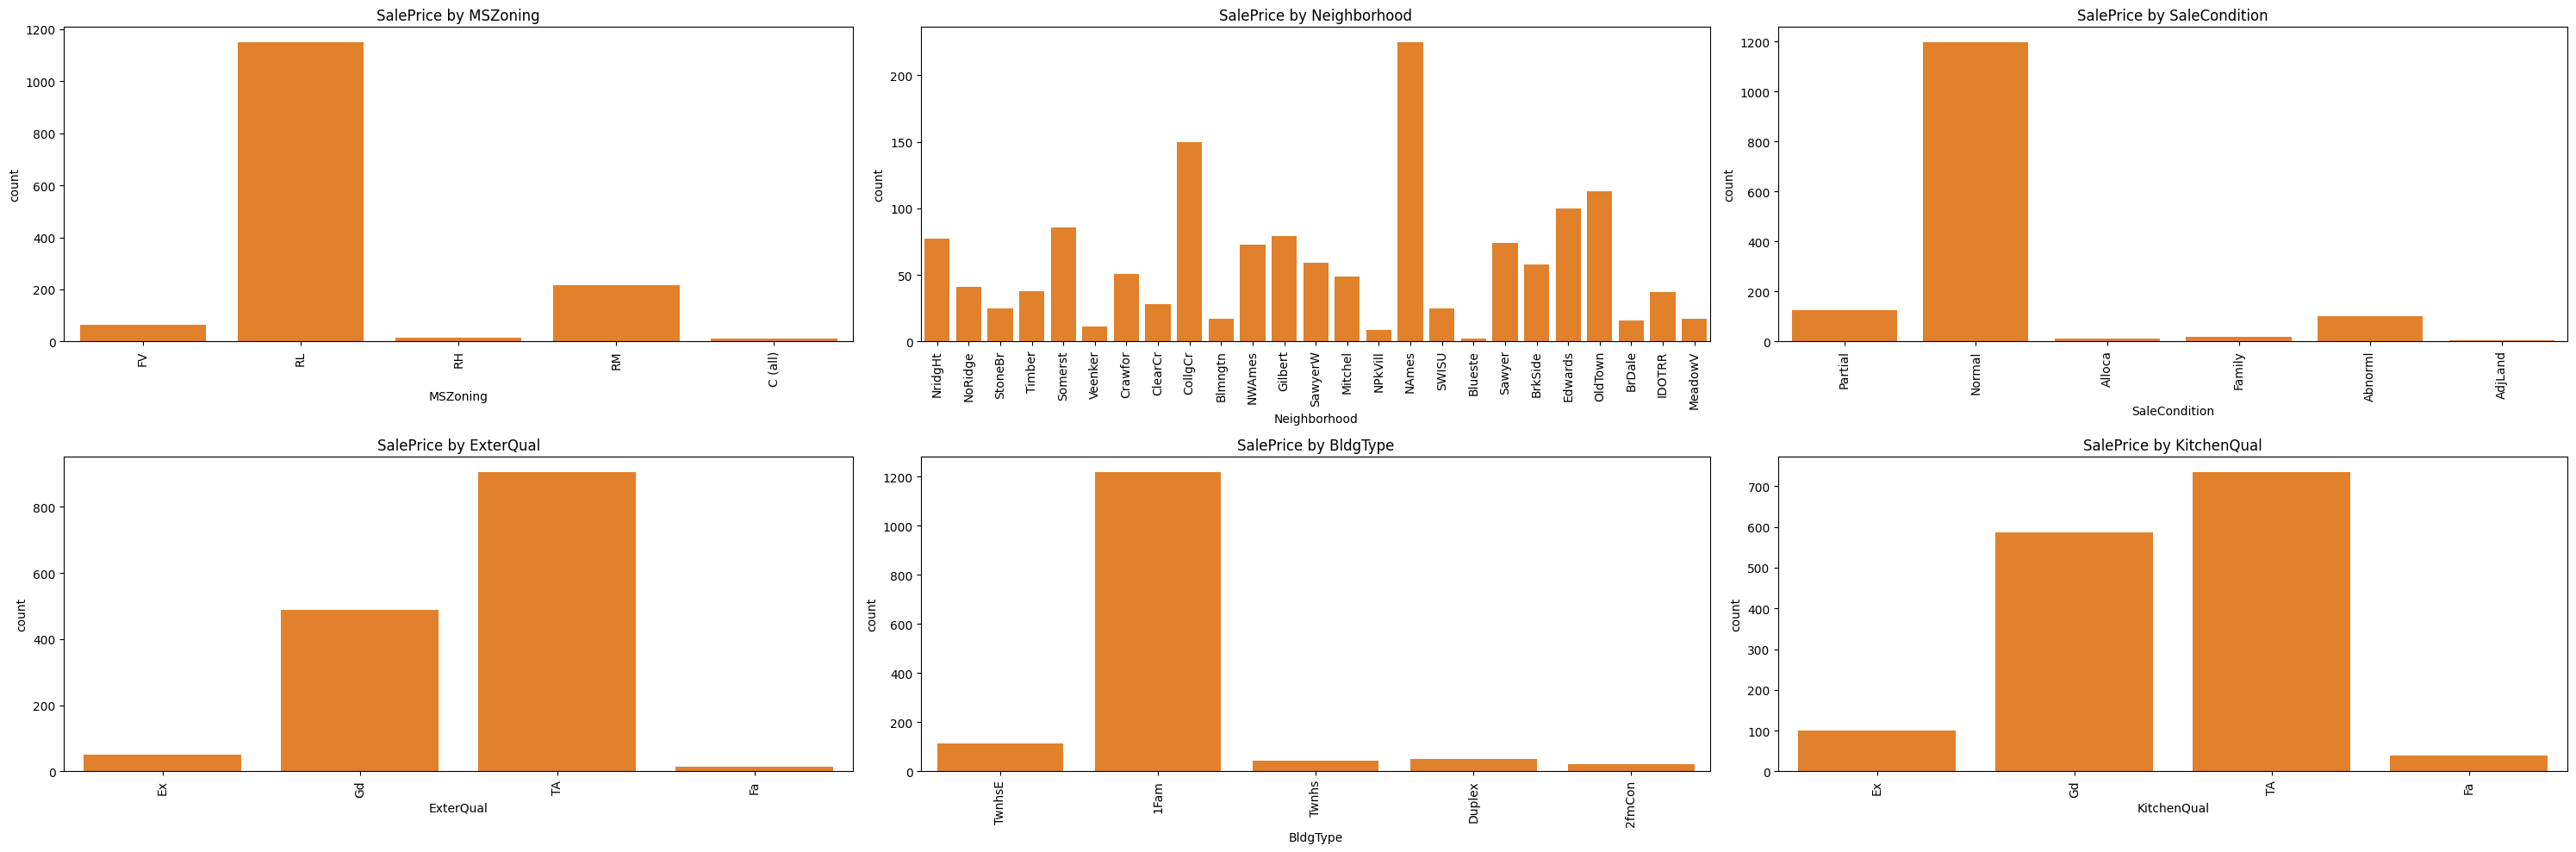

In [ ]:
# Visualization
# plot count distributions for top categorical features

new_cat_features = ['MSZoning','Neighborhood','SaleCondition','ExterQual','BldgType','KitchenQual']

plt.figure(figsize=(30, 10))
for i, features in enumerate(new_cat_features):
  plt.subplot(2, 3, i+1)
  order = df2.groupby(features)['SalePrice'].median().sort_values(ascending = False).index
  sns.countplot(x = features, data = df2, order = order)
  sns.countplot(x = df2[features])
  plt.title(f'SalePrice by {features}')
  plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()


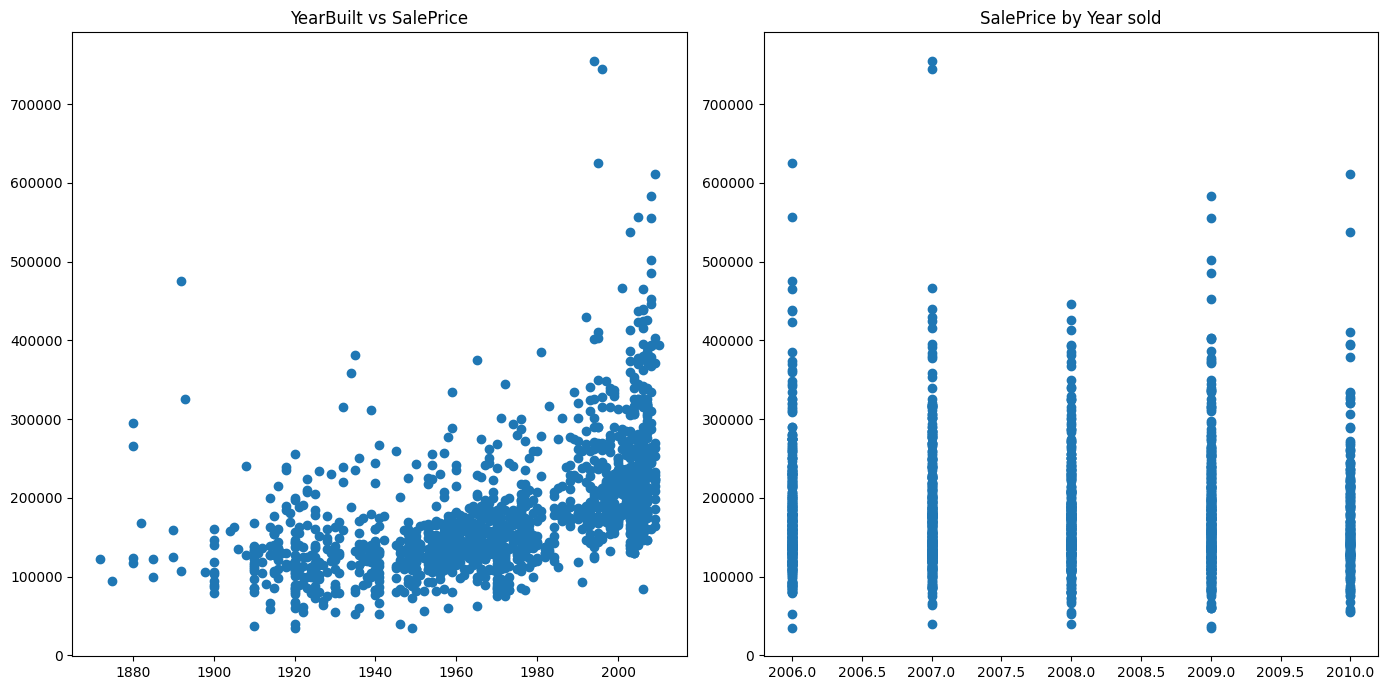

In [ ]:
# Visualization
# Year features analysis:
plt.figure(figsize = (14, 7))
plt.subplot(1, 2, 1)
plt.scatter(x = 'YearBuilt', y= 'SalePrice', data=df2)
plt.title('YearBuilt vs SalePrice')

plt.subplot(1, 2, 2)
plt.scatter(x= 'YrSold', y= 'SalePrice', data=df2)
plt.title('SalePrice by Year sold')

plt.tight_layout()
plt.show()